# 데이터 시각화 (Data Visualization)

In [40]:
import numpy as np
import pandas as pd
import json
import re # 정규 표현식 사용
import matplotlib.pyplot as plt # 데이터 시각화

from matplotlib_venn import venn2

## 정형 데이터 (Structured Data)

### 1. 1번 미니 퀘스트
- 샘플 데이터프레임을 생성한 후, 데이터의 기본 정보를 출력하는 코드 작성

In [ ]:
# 샘플 데이터 생성
data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동'],
    '나이': [25, 30, 35, 28, 40],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO'],
    '연봉': [4000, 3500, 5000, 4200, 10000],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27']
}

df = pd.DataFrame(data)

# 데이터 프레임 기본 정보 확인
print(df.info(), "\n") # 기본 정보 출력
print(df.head(), "\n") # 상위 데이터 확인
print(df.describe(), "\n") # 통계 정보 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   이름      5 non-null      object
 1   나이      5 non-null      int64 
 2   직업      5 non-null      object
 3   연봉      5 non-null      int64 
 4   가입일     5 non-null      object
dtypes: int64(2), object(3)
memory usage: 332.0+ bytes
None 

    이름  나이    직업     연봉         가입일
0  김철수  25   개발자   4000  2020-05-21
1  이영희  30   마케터   3500  2019-07-15
2  박민수  35   개발자   5000  2021-01-10
3  최지현  28  디자이너   4200  2018-11-03
4  홍길동  40   CEO  10000  2017-09-27 

             나이           연봉
count   5.00000      5.00000
mean   31.60000   5340.00000
std     5.94138   2660.45109
min    25.00000   3500.00000
25%    28.00000   4000.00000
50%    30.00000   4200.00000
75%    35.00000   5000.00000
max    40.00000  10000.00000 



### 2. 2번 미니 퀘스트
- 샘플 데이터에서 나이가 30 이상이고 연봉이 5000 이하인 사람들만 필터링하는 코드 작성

In [ ]:
# 샘플 데이터 생성
data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동', '정지훈', '이지은'],
    '나이': [25, 30, 35, 28, 40, 50, 22],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO', '디자이너', '마케터'],
    '연봉': [4000, 3500, 5000, 4200, 10000, 4600, 3300],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27', '2016-04-11', '2022-03-19']
}

df = pd.DataFrame(data)

# 조건 필터링
filtered = df[(df['나이'] >= 30) & (df['연봉'] <= 5000)]
print(filtered)

    이름  나이    직업    연봉         가입일
1  이영희  30   마케터  3500  2019-07-15
2  박민수  35   개발자  5000  2021-01-10
5  정지훈  50  디자이너  4600  2016-04-11


### 3. 3번 미니 퀘스트
- 샘플 데이터에서 가입 연도가 2019년 이전인 사람들을 찾아 연봉을 10% 인상한 후, 전체 평균 연봉을 계산하는 코드 작성

In [ ]:
# 샘플 데이터 생성
data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동', '정지훈', '이지은'],
    '나이': [25, 30, 35, 28, 40, 50, 22],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO', '디자이너', '마케터'],
    '연봉': [4000, 3500, 5000, 4200, 10000, 4600, 3300],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27', '2016-04-11', '2022-03-19']
}

df = pd.DataFrame(data)

# 가입 연도 조건 필터링
df['가입일'] = pd.to_datetime(df['가입일']) # 가입일을 datetime 타입으로 변환
df['가입연도'] = df['가입일'].dt.year # 가입 연도 추출

# 가입 연도에 따라 연봉 10% 인상
df['연봉'] = df['연봉'].astype(float)
df.loc[df['가입연도'] <= 2019, '연봉'] *= 1.1

# 전체 평균 연봉 계산
average_salary = df['연봉'].mean()

print(df, "\n")
print(average_salary)

    이름  나이    직업       연봉        가입일  가입연도
0  김철수  25   개발자   4000.0 2020-05-21  2020
1  이영희  30   마케터   3850.0 2019-07-15  2019
2  박민수  35   개발자   5000.0 2021-01-10  2021
3  최지현  28  디자이너   4620.0 2018-11-03  2018
4  홍길동  40   CEO  11000.0 2017-09-27  2017
5  정지훈  50  디자이너   5060.0 2016-04-11  2016
6  이지은  22   마케터   3300.0 2022-03-19  2022 

5261.428571428572




---



## 비정형 데이터 (Unstructured Data)

### 1. 1번 미니 퀘스트
- JSON 형식의 데이터를 직접 생성한 후, Pandas 데이터프레임으로 변환하는 코드 작성

In [3]:
data = '''
[
    {"이름": "김철수", "나이": 25, "직업": "개발자", "연봉": 4000},
    {"이름": "이영희", "나이": 30, "직업": "마케터", "연봉": 3500},
    {"이름": "박민수", "나이": 35, "직업": "디자이너", "연봉": 4200}
]
'''

# json 생성
json_data = json.loads(data)

# DataFrame 변환
df = pd.DataFrame(json_data)

print(df)

    이름  나이    직업    연봉
0  김철수  25   개발자  4000
1  이영희  30   마케터  3500
2  박민수  35  디자이너  4200


### 2. 2번 미니 퀘스트
- 샘플 데이터에서 한글과 공백을 제외한 모든 문자를 제거하고, 공백을 하나로 정리하는 코드 작성

In [6]:
from typing import Text
text = "안녕하세요!!! 저는 AI 모델-입니다. 12345 데이터를   정리해 보겠습니다."

# 한글과 공백을 제외한 문자 제거
clean_text = re.sub(r"[^가-힣\s]", "", text)

# 연속 공백 제거
clean_text = re.sub(r"\s+", " ", clean_text).strip()

print(clean_text)

안녕하세요 저는 모델입니다 데이터를 정리해 보겠습니다


### 3. 3번 미니 퀘스트
- 주어진 텍스트 데이터를 문장 단위로 분리한 후, 각 문장의 단어 개수를 데이터프레임으로 변환하는 코드 작성

In [7]:
text = "자연어 처리는 재미있다. 파이썬과 pandas를 활용하면 편리하다. 데이터 분석은 흥미롭다."

# 문장 단위 분리
sentences = [s.strip() for s in text.split('.') if s.strip()]

data = []

for sentence in sentences:
  words = sentence.split()
  word_count = len(words)
  data.append({'문장': sentence, '단어 개수': word_count})

df = pd.DataFrame(data)
print(df)

                       문장  단어 개수
0            자연어 처리는 재미있다      3
1  파이썬과 pandas를 활용하면 편리하다      4
2            데이터 분석은 흥미롭다      3




---



## 막대그래프 (Bar Chart)

### 1. 1번 미니 퀘스트
- matplotlib를 활용해 5개의 카테고리와 각각의 값이 포함된 기본 세로 막대 그래프를 생성

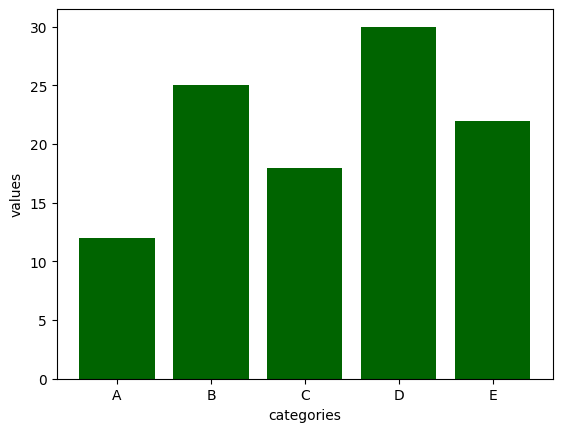

In [14]:
categories = ['A', 'B', 'C', 'D', 'E']
values = [12, 25, 18, 30, 22]

# 막대 그래프 생성
plt.bar(categories, values, color='darkgreen')

plt.xlabel("categories")
plt.ylabel("values")


# 그래프 표시
plt.show()

### 2. 2번 미니 퀘스트
- 누적형 막대 그래프를 생성하여, 두 개의 연도별 데이터를 각각 다른 색상으로 누적하여 표현

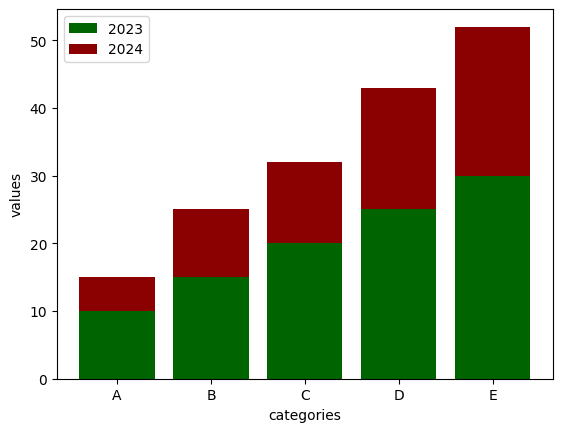

In [16]:
categories = ['A', 'B', 'C', 'D', 'E']
values_2023 = [10, 15, 20, 25, 30]
values_2024 = [5, 10, 12, 18, 22]

# 막대 위치 설정
x = np.arange(len(categories))

# 누적형 막대 그래프 생성
plt.bar(x, values_2023, color='darkgreen', label='2023')
plt.bar(x, values_2024, bottom=values_2023, color='darkred', label='2024')

# 축 설정
plt.xticks(x, categories) # x축 눈금(labels)을 categories 리스트로 설정
plt.xlabel("categories")
plt.ylabel('values')
plt.legend() # 범례 추가

# 그래프 표시
plt.show()

### 3. 3번 미니 퀘스트
- 한 기업의 부서별 연간 성과(2023년 vs 2024년)를 비교하는 그룹형 막대 그래프를 생성

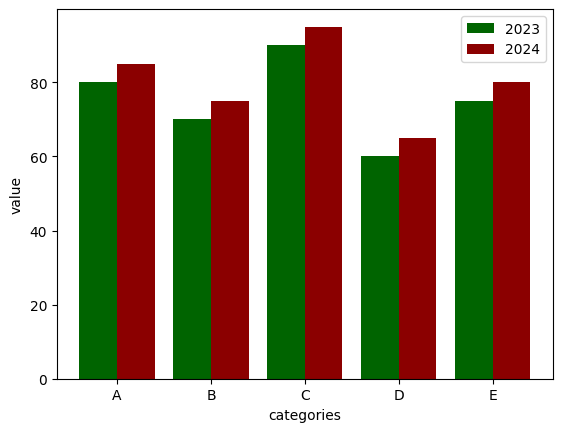

In [17]:
departments = ['Sales', 'Marketing', 'IT', 'HR', 'Finance']
performance_2023 = [80, 70, 90, 60, 75]
performance_2024 = [85, 75, 95, 65, 80]

# 막대 너비 설정
bar_width = 0.4

# 막대 위치 설정
x = np.arange(len(categories))

# 그룹형 막대 그래프 생성
plt.bar(x - bar_width/2, performance_2023, bar_width, label='2023', color='darkgreen')
plt.bar(x + bar_width/2, performance_2024, bar_width, label='2024', color='darkred')

# 축 설정
plt.xticks(x, categories) # x축 눈금을 categories 리스트로 설정
plt.xlabel("categories")
plt.ylabel("value")
plt.legend() # 범례 추가

# 그래프 표시
plt.show()



---



## 히스토그램 (Histogram)

### 1. 1번 미니 퀘스트
- 정규 분포를 따르는 1000개의 데이터를 생성한 후, 구간을 15개로 설정한 히스토그램을 그리는 코드 작성

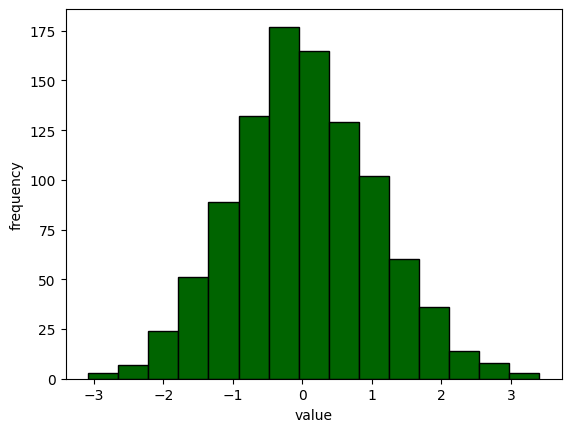

In [18]:
# 정규 분포를 따르는 1000개의 데이터 생성
data = np.random.randn(1000) # 평균 0, 표준편차 1인 정규 분포에서 1000개의 데이터 추출

# 기본 히스토그램 생성
plt.hist(data, bins=15, color='darkgreen', edgecolor='black')
plt.xlabel("value")
plt.ylabel("frequency")

# 그래프 표시
plt.show()

### 2. 2번 미니 퀘스트
- 두 개의 서로 다른 정규 분포를 따르는 데이터셋을 생성한 후, 두 히스토그램을 같은 그래프에서 겹쳐서 비교

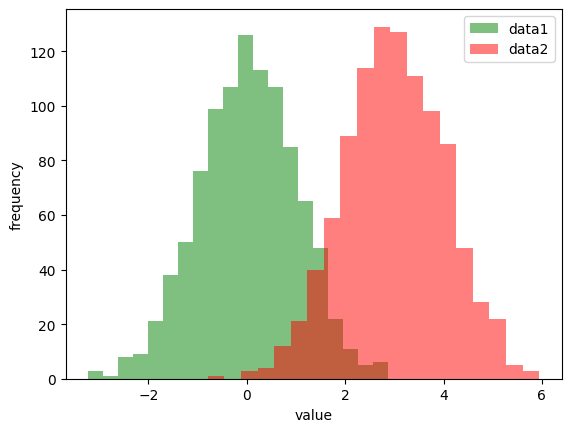

In [22]:
# 첫 번째 데이터셋 (평균 0, 표준편차 1)
data1 = np.random.randn(1000)

# 두 번째 데이터셋 (평균 3, 표준편차 1)
data2 = np.random.randn(1000) + 3

plt.hist(data1, bins=20, alpha=0.5, label='data1', color='green')
plt.hist(data2, bins=20, alpha=0.5, label='data2', color='red')

plt.xlabel("value")
plt.ylabel("frequency")
plt.legend()

# 그래프 표시
plt.show()

### 3. 3번 미니 퀘스트
- 한 데이터셋의 누적 히스토그램을 그린 후, X축과 Y축의 적절한 레이블을 설정

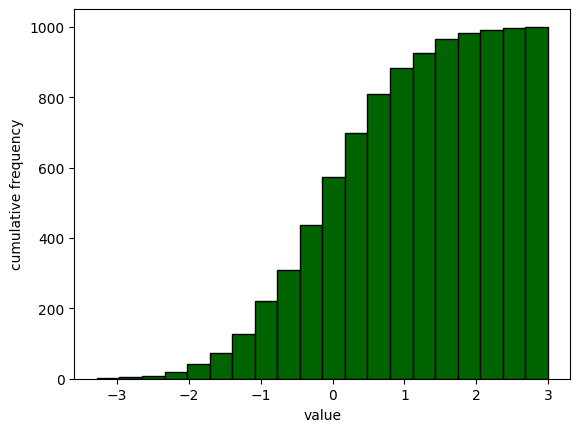

In [24]:
data = np.random.randn(1000)

# 누적 히스토그램
plt.hist(data, bins=20, cumulative=True, color='darkgreen', edgecolor='black')

plt.xlabel('value')
plt.ylabel('cumulative frequency')

plt.show()



---



## 산점도 (Scatter Plot)

### 1. 1번 미니 퀘스트
- 두 개의 리스트 x = [1, 2, 3, 4, 5], y = [3, 1, 4, 5, 2]를 사용하여 산점도를 그리고, X축과 Y축의 라벨 추가

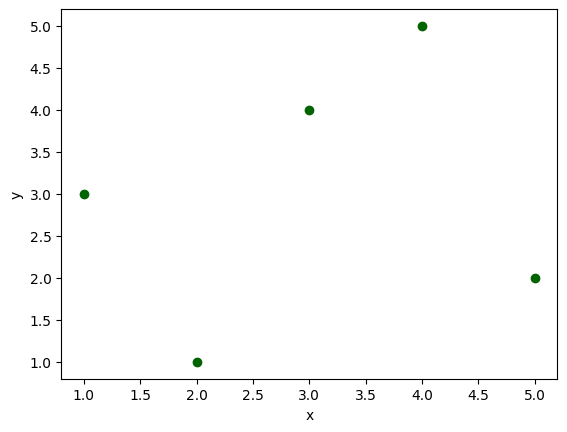

In [25]:
# 데이터 생성
x = [1, 2, 3, 4, 5]
y = [3, 1, 4, 5, 2]

# 산점도 생성
plt.scatter(x, y, color='darkgreen', marker='o')

plt.xlabel('x')
plt.ylabel('y')

# 그래프 표시
plt.show()

### 2. 2번 미니 퀘스트
- numpy를 활용하여 난수를 생성한 후, 산점도를 그리고 점의 색상과 투명도를 설정

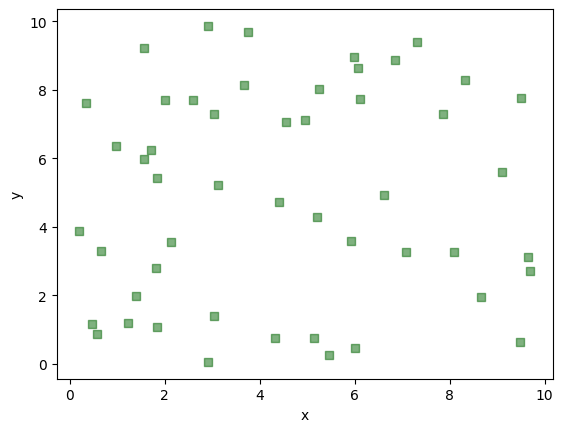

In [29]:
# 난수 데이터 생성
np.random.seed(42)
x = np.random.rand(50) * 10  # 0~10 범위의 난수 50개
y = np.random.rand(50) * 10  # 0~10 범위의 난수 50개

# 산점도 생성
# alpha: 점 투명도 설정
plt.scatter(x, y, color='darkgreen', marker='s', alpha=0.5)

plt.xlabel('x')
plt.ylabel('y')

plt.show()

### 3. 3번 미니 퀘스트
- numpy를 활용하여 세 개의 그룹('A', 'B', 'C')에 속하는 데이터의 산점도를 서로 다른 색상으로 그리기

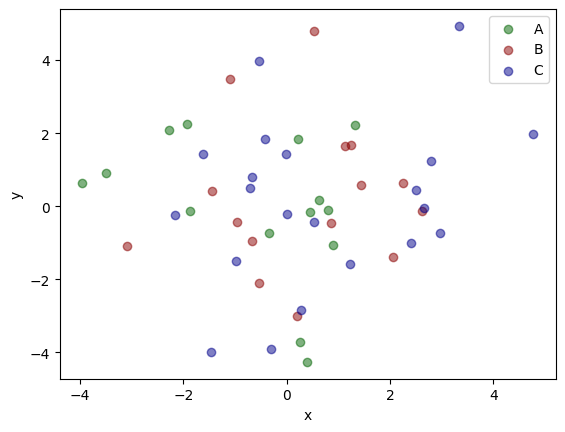

In [30]:
# 데이터 생성
np.random.seed(10)
x = np.random.randn(50) * 2
y = np.random.randn(50) * 2
categories = np.random.choice(['A', 'B', 'C'], size=50)

# 카테고리별 색상 지정
color = {'A': 'darkgreen', 'B': 'darkred', 'C': 'darkblue'}

# 산점도 생성
for cat in ['A', 'B', 'C']:
  plt.scatter(x[categories == cat], y[categories == cat], color=color[cat], label=cat, alpha=0.5)

plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.show()



---



## 박스 플롯 (Box Plot)

### 1. 1번 미니 퀘스트
- 평균 0, 표준편차 1을 따르는 정규분포 난수 50개를 생성한 후, 해당 데이터를 이용해 기본 박스 플롯을 출력

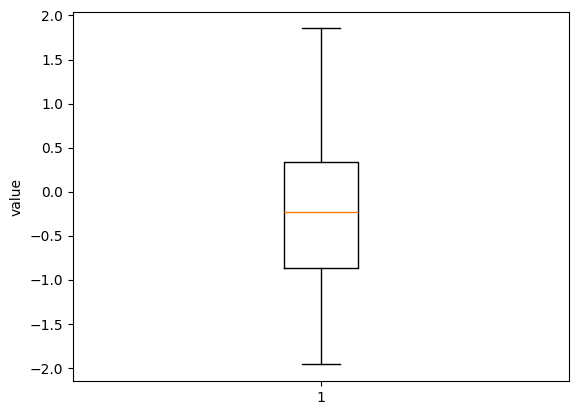

In [31]:
# 정규분포를 따르는 난수 50개 생성
np.random.seed(42) # 랜덤 시드 고정 (재현 가능성 보장)
data = np.random.randn(50)

# 박스 플롯 생성
plt.boxplot(data)
plt.ylabel('value')

plt.show()

### 2. 2번 미니 퀘스트
- 세 개의 그룹(Group A, Group B, Group C) 에 대해 각각 다른 평균을 가지는 데이터를 생성하고, 이를 이용해 다중 박스 플롯 그리기

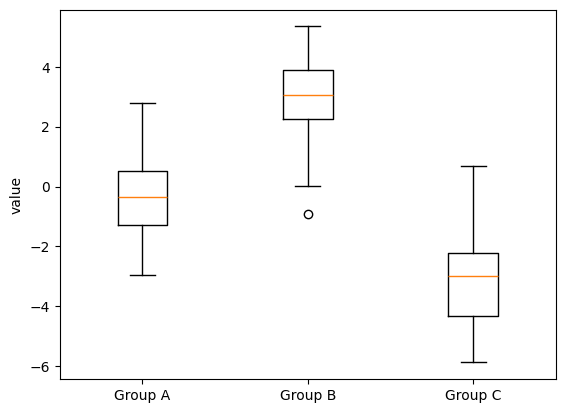

In [33]:
# 랜덤 데이터 생성 (각 그룹별 평균 다르게 설정)
np.random.seed(42)
group_a = np.random.randn(50) * 1.5  # 표준편차 1.5, 평균 0
group_b = np.random.randn(50) * 1.5 + 3  # 표준편차 1.5, 평균 3
group_c = np.random.randn(50) * 1.5 - 3  # 표준편차 1.5, 평균 -3

# 여러 개의 박스 플롯 생성
plt.boxplot([group_a, group_b, group_c], tick_labels=['Group A', 'Group B', 'Group C'])
plt.ylabel('value')

plt.show()

### 3. 3번 미니 퀘스트
- 평균이 **서로 다른 두 개의 그룹(Group X, Group Y)** 을 비교하는 박스 플롯 그리기
(단, **이상값을 강조하고, 스타일을 커스터마이징**해야 함)

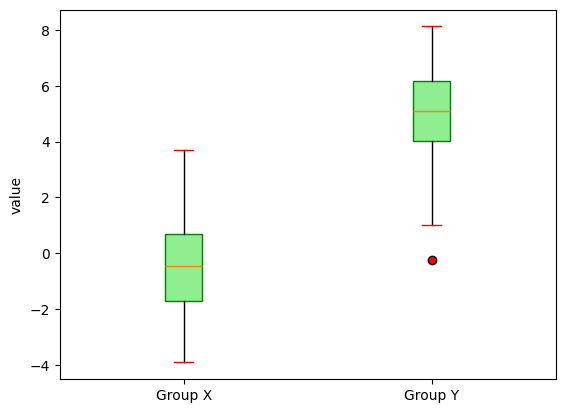

In [35]:
# 랜덤 데이터 생성 (두 그룹의 평균 다르게 설정)
np.random.seed(42)
group_x = np.random.randn(50) * 2  # 표준편차 2, 평균 0
group_y = np.random.randn(50) * 2 + 5  # 표준편차 2, 평균 5

# 서로 다른 그룹 비교
plt.boxplot([group_x, group_y],
            tick_labels=['Group X', 'Group Y'],
            patch_artist=True, # 박스 내부 색상 채우기
            boxprops=dict(facecolor="lightgreen", color="green"), # 박스 색상 설정
            whiskerprops=dict(color='black'), # 수염 색상 설정
            capprops=dict(color='red'), # 상/하한성 색상 설정
            flierprops=dict(marker='o', markerfacecolor='red', markersize=6) # 이상값 강조
            )
plt.ylabel('value')



plt.show()



---



## 고급 다중 그래프 (Advanced Multiple Graphs)

### 1. 1번 미니 퀘스트
- `plt.subplots()`를 사용하여 2x1 형태의 서브플롯을 만들고, 첫 번째 서브플롯에는 `y = x^2`, 두 번째 서브플롯에는 `y = x^3`을 그리기

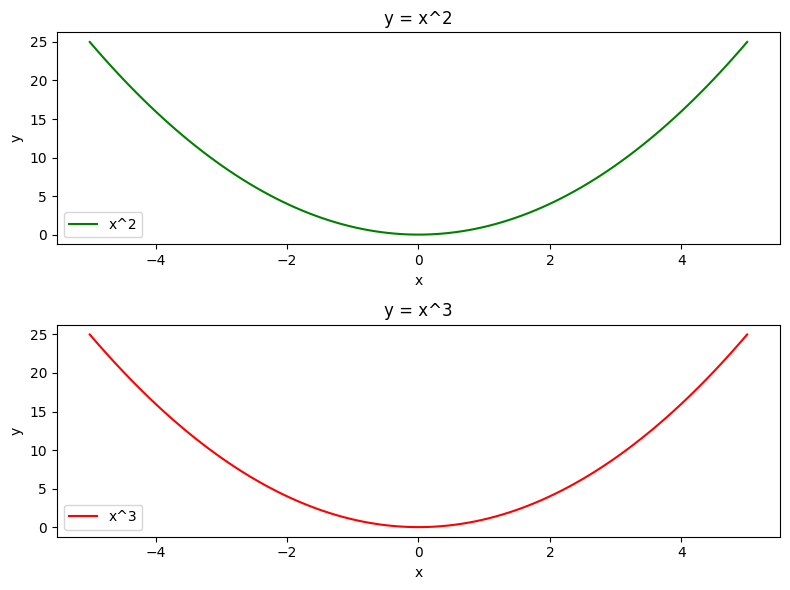

In [37]:
# 데이터 생성
x = np.linspace(-5, 5, 100)
y1 = x ** 2  # x의 제곱
y2 = x ** 3  # x의 세제곱

# 서브플롯 설정 (2행 1열)
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 6))

# 첫 번째 서브플롯
axes[0].plot(x, y1, color='green', label='x^2')  # 첫 번째 서브플롯에 그래프 추가
axes[0].set_title("y = x^2")  # 제목 설정
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# 두 번째 서브플롯
axes[1].plot(x, y1, color='red', label='x^3')  # 두 번째 서브플롯에 그래프 추가
axes[1].set_title("y = x^3")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()

# 전체 레이아웃 조정
plt.tight_layout()  # 그래프 간 간격 자동 조정

plt.show()

### 2. 2번 미니 퀘스트
- X축을 공유하는 1행 2열 형태의 서브플롯을 생성하고, 첫 번째 서브플롯에는 정규 분포를 따르는 난수의 히스토그램, 두 번째 서브플롯에는 균등 분포를 따르는 난수의 히스토그램 그리기

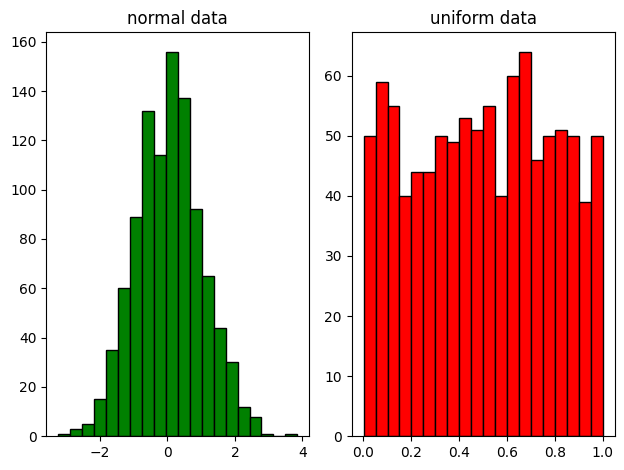

In [38]:
# 데이터 생성
normal_data = np.random.randn(1000)  # 정규 분포 난수 1000개
uniform_data = np.random.rand(1000)  # 균등 분포 난수 1000개

# 서브플롯 설정 (1행 2열)
fig, axes = plt.subplots(nrows=1, ncols=2)

# 첫 번째 서브플롯
axes[0].hist(normal_data, bins=20, color='green', edgecolor='black')
axes[0].set_title("normal data")

# 두 번째 서브플롯
axes[1].hist(uniform_data, bins=20, color='red', edgecolor='black')
axes[1].set_title("uniform data")

plt.tight_layout()
plt.show()

### 3. 3번 미니 퀘스트
- `gridspec`을 사용하여 불규칙한 레이아웃의 서브플롯을 생성하고, 각각 선 그래프, 산점도, 막대 그래프, 히스토그램 그리기

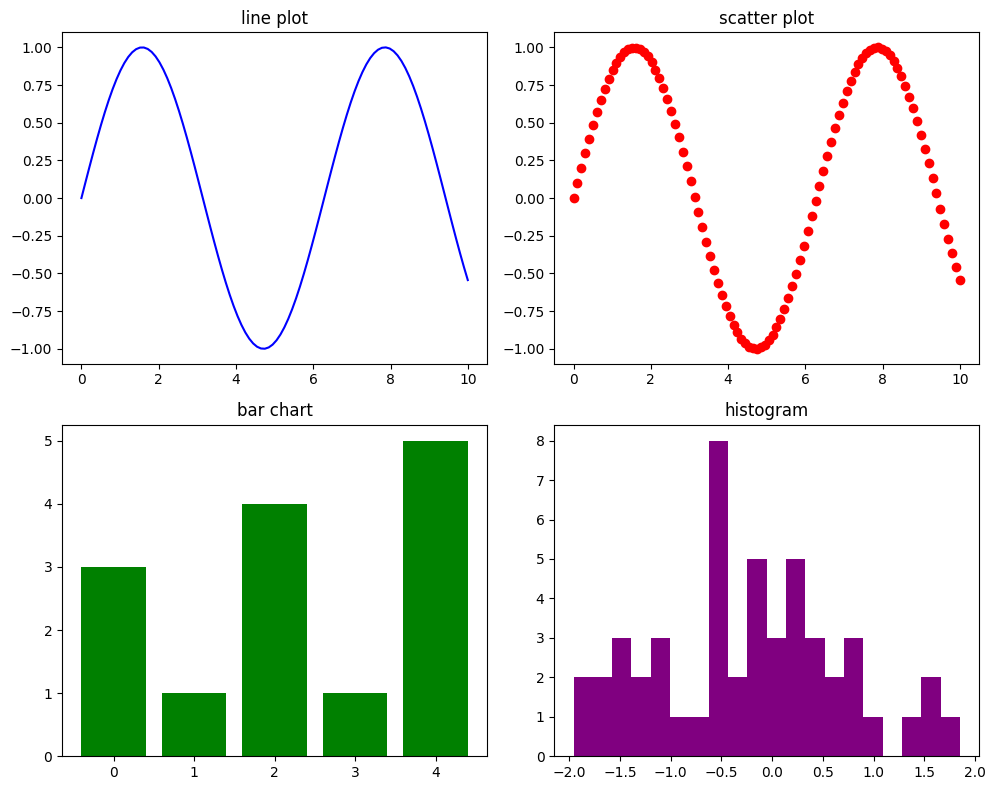

In [39]:
# 데이터 생성
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.random.randn(100)
categories = ['A', 'B', 'C', 'D', 'E']
values = [3, 7, 5, 2, 8]

# 2x2 서브플롯 생성, 크기는 10x8 인치
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 선 그래프
axes[0, 0].plot(x, y1, color='blue')
axes[0, 0].set_title("line plot")

# 산점도
axes[0, 1].scatter(x, y1, color='red')
axes[0, 1].set_title("scatter plot")

# 막대 그래프
axes[1, 0].bar(np.arange(5), [3, 1, 4, 1, 5], color='green')
axes[1, 0].set_title("bar chart")

# 히스토그램
axes[1, 1].hist(data, bins=20, color='purple')
axes[1, 1].set_title("histogram")

# 그래프 출력
plt.tight_layout()
plt.show()



---



## 벤 다이어그램 (Venn diagram)

### 1. 1번 미니 퀘스트
- 두 개의 과일 집합을 정의하고, 두 집합의 차집합(한 집합에만 존재하는 요소)을 출력

In [46]:
# 두 개의 과일 집합 정의
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}

print("A - B :", set_A - set_B) # A에만 존재하는 요소
print("B - A :", set_B - set_A) # B에만 존재하는 요소

A - B : {'체리', '사과'}
B - A : {'수박', '포도'}


### 2. 2번 미니 퀘스트
- 벤 다이어그램을 그리지 않고, 세 개의 집합을 비교하여 각 집합이 단독으로 가지는 요소 개수와 교집합 개수 계산

In [45]:
# 세 개의 과일 집합 정의
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}
set_C = {"망고", "수박", "딸기", "오렌지"}

# 각 집합만 단독으로 가지는 요소
only_A = set_A - set_B - set_C
only_B = set_B - set_A - set_C
only_C = set_C - set_A - set_B

# 교집합
A_B = set_A & set_B
A_C = set_A & set_C
B_C = set_B & set_C

# 세 집합 공통 교집합
A_B_C = set_A & set_B & set_C

print("A만:", only_A, "개수:", len(only_A))
print("B만:", only_B, "개수:", len(only_B))
print("C만:", only_C, "개수:", len(only_C), "\n")

print("A∩B:", A_B, "개수:", len(A_B))
print("A∩C:", A_C, "개수:", len(A_C))
print("B∩C:", B_C, "개수:", len(B_C), "\n")

print("A∩B∩C:", A_B_C, "개수:", len(A_B_C))

A만: {'체리', '사과'} 개수: 2
B만: {'포도'} 개수: 1
C만: {'딸기', '오렌지'} 개수: 2 

A∩B: {'바나나', '망고'} 개수: 2
A∩C: {'망고'} 개수: 1
B∩C: {'수박', '망고'} 개수: 2 

A∩B∩C: {'망고'} 개수: 1


### 3. 3번 미니 퀘스트
- 벤 다이어그램을 그리면서, 특정 조건을 만족하는 경우 색상을 다르게 지정하는 코드
  - **조건:** 두 개의 집합을 비교할 때, **교집합이 2개 이상이면 노란색, 그렇지 않으면 기본 색상**

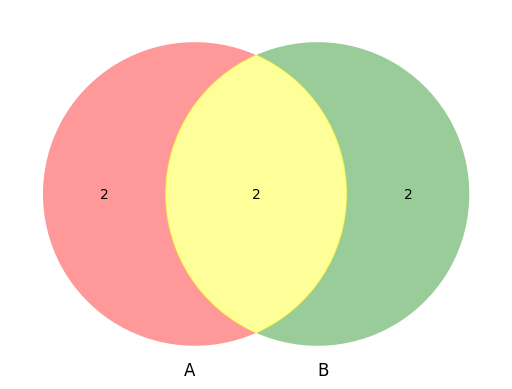

In [47]:
# 두 개의 집합 정의
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}

# 교집합 개수 계산
intersection_count = len(set_A & set_B)

# 벤 다이어그램 생성
venn = venn2(
    [set_A, set_B],
    set_labels=('A', 'B')
)

# 조건에 따른 색상 변경
if intersection_count >= 2:
    venn.get_patch_by_id('11').set_color('yellow') # '11' -> A와 B 모두 포함되는 교집합 영역

plt.show()



---

